<a href="https://colab.research.google.com/github/rohitptnk/Former/blob/main/CosmoFormer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set Parameters

In [1]:
# 400K PARAMS

d_model = 128
num_heads = 8
num_layers = 4
dim_feedforward = 256
dropout = 0.1
batch_size = 32
learning_rate = 1e-5
max_epochs = 3000
save_every = 100

In [2]:
# 100K PARAMS

# d_model = 64
# num_heads = 4
# num_layers = 3
# dim_feedforward = 128
# dropout = 0.1
# batch_size = 32
# learning_rate = 1e-5
# max_epochs = 1000
# save_every = 100

Imports

In [3]:
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import os

# Dataset Class

In [4]:
base_path = '/content/drive/MyDrive/Study Materials/MS Thesis/Code/10k data/' # For rohit21 account
# base_path = '/content/drive/MyDrive/Projects/CosmoFormer Temp/' # For rohitptnk account

In [5]:
class ClDataset(Dataset):
    def __init__(self, noisy_path, true_path, eps=1e-10):
        # Load NumPy arrays
        noisy = np.load(noisy_path)  # shape: (num_samples, seq_len)
        true  = np.load(true_path)

        assert noisy.shape == true.shape, "Input and target shapes must match!"

        self.eps = eps

        # Apply log-scaling
        # self.noisy = torch.tensor(np.log10(noisy + self.eps), dtype=torch.float32)
        # self.true  = torch.tensor(np.log10(true + self.eps), dtype=torch.float32)

        # Apply standard sccaling
        # Compute mean and std from training data
        mean = np.mean(noisy)
        std = np.std(noisy)
        self.mean_np = mean
        self.std_np = std
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        # Standardize data (done in numpy first)
        self.noisy = torch.tensor((noisy - mean) / std, dtype=torch.float32)
        self.true  = torch.tensor((true - mean) / std, dtype=torch.float32)
        torch.save({'mean': self.mean, 'std': self.std}, f"{base_path}/400k std scaled/scaler.pth")


    def __len__(self):
        return self.noisy.shape[0]

    def __getitem__(self, idx):
        return self.noisy[idx], self.true[idx]

    def inverse_transform(self, arr):
        # Convert normalized tensor back to original scale (Torch-only).
        if not torch.is_tensor(arr):
            arr = torch.tensor(arr, dtype=torch.float32)
        return arr * self.std.to(arr.device) + self.mean.to(arr.device)


# Train Test Split

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
dataset = ClDataset(f"{base_path}noisy_cls.npy", f"{base_path}true_cls.npy")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Positional Encoding

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [9]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, seq_len):
        super().__init__()
        # Learnable positional embeddings
        self.pos_embedding = nn.Embedding(seq_len, d_model)
        self.register_buffer('positions', torch.arange(seq_len).unsqueeze(0))  # shape (1, seq_len)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        positions = self.positions[:, :x.size(1)].to(x.device)
        pos_emb = self.pos_embedding(positions)  # (1, seq_len, d_model)
        return x + pos_emb


# Transformer Block

In [10]:
class Transformer1DAutoencoder(nn.Module):
    def __init__(self, seq_len, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        # input embedding (1D scalar → d_model)
        self.input_proj = nn.Linear(1, d_model)

        # positional encoding
        self.pos_encoder = LearnablePositionalEncoding(d_model, seq_len)
        # self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        # encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # batch_first=True makes input shape (batch, seq_len, d_model)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # output projection (d_model → scalar)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len)
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)  # add positional encoding
        x = self.encoder(x)      # Transformer Encoder
        x = self.output_proj(x)  # (batch, seq_len, 1)
        return x.squeeze(-1)     # (batch, seq_len)

# Initialize model, loss and optimizer

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer1DAutoencoder(
    seq_len=dataset.noisy.shape[1],  # sequence length = lmax
    d_model=d_model,
    nhead=num_heads,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Checkpoint if exists

In [16]:
checkpoint_dir = f"{base_path}/400k std scaled/checkpoints" # Save checkpoints to Google Drive
os.makedirs(checkpoint_dir, exist_ok=True)
start_epoch = 0
checkpoint_path = os.path.join(checkpoint_dir, "checkpoint_epoch_2500.pth")

In [17]:
# Resume from checkpoint if exists
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    # start_epoch = 0
    print(f"Resuming training from epoch {start_epoch} from {checkpoint_path}")

Resuming training from epoch 2500 from /content/drive/MyDrive/Study Materials/MS Thesis/Code/10k data//400k std scaled/checkpoints/checkpoint_epoch_2500.pth


# Training Code

In [41]:
loss_list_path = f'{base_path}/400k std scaled/loss_list.npy'
if os.path.exists(loss_list_path):
  loss_list = np.load(loss_list_path).tolist()
  print(f"loaded losses from {loss_list_path}")
else:
  loss_list = []
print(len(loss_list))

loaded losses from /content/drive/MyDrive/Study Materials/MS Thesis/Code/10k data//400k std scaled/loss_list.npy
10


In [ ]:
num_epochs = 3000

for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0
    for noisy, true in train_loader:
        noisy, true = noisy.to(device), true.to(device)

        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, true)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Save checkpoint
    if (epoch + 1) % save_every == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_loss
        }, checkpoint_path)
        loss_list.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_loss:.6f}")
        print(f"Checkpoint saved at epoch {epoch+1}")

np.save(f"{base_path}/400k std scaled loss_list.npy", np.array(loss_list))

Epoch [2100/3000] | Train Loss: 0.066174
Checkpoint saved at epoch 2100
Epoch [2200/3000] | Train Loss: 0.064564
Checkpoint saved at epoch 2200
Epoch [2300/3000] | Train Loss: 0.063105
Checkpoint saved at epoch 2300
Epoch [2400/3000] | Train Loss: 0.061955
Checkpoint saved at epoch 2400
Epoch [2500/3000] | Train Loss: 0.060795
Checkpoint saved at epoch 2500


# Evaluation

In [19]:
model.eval()
test_loss = 0
with torch.no_grad():
    for noisy, true in test_loader:
        noisy, true = noisy.to(device), true.to(device) #change dtype
        output = model(noisy)
        # output_original = dataset.inverse_transform(output)
        # true_original = dataset.inverse_transform(true)
        loss = criterion(output, true)
        test_loss += loss.item()

print(f"Test MSE: {test_loss/len(test_loader):.6f}")

Test MSE: 0.055617


# Visualization

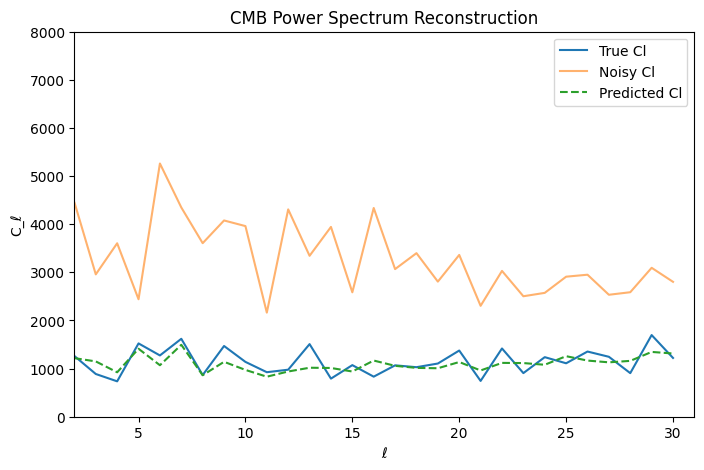

In [22]:
import matplotlib.pyplot as plt

noisy, true = next(iter(test_loader))
noisy, true = noisy.to(device), true.to(device)
pred = model(noisy).cpu().detach().numpy()

true = dataset.inverse_transform(true)
pred = dataset.inverse_transform(pred)
noisy = dataset.inverse_transform(noisy)

idx = 1  # sample index
plt.figure(figsize=(8,5))
plt.plot(true[idx].cpu(), label="True Cl")
plt.plot(noisy[idx].cpu(), label="Noisy Cl", alpha=0.6)
plt.plot(pred[idx], label="Predicted Cl", linestyle="--")
plt.legend()
plt.xlim([2, len(true[idx])])
plt.ylim(0, 8000)
plt.xlabel("ℓ")
plt.ylabel("C_ℓ")
plt.title("CMB Power Spectrum Reconstruction")
pic_path = f'{base_path}/400k std scaled/Plots/'
plt.savefig(f'{pic_path}sample{idx}.png')
plt.show()

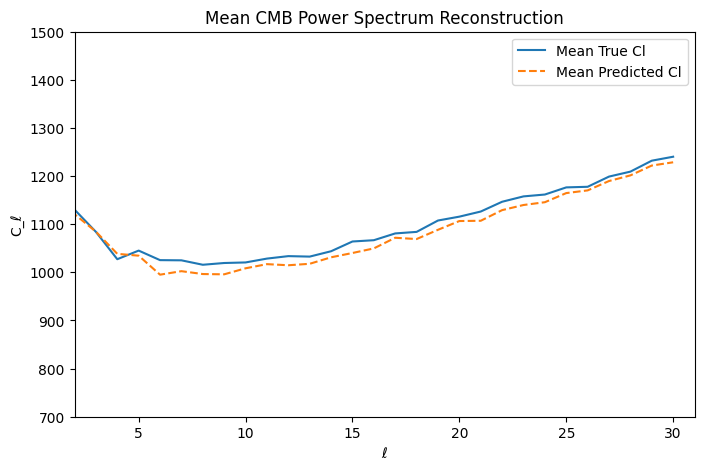

In [23]:
model.eval()
true_values = []
pred_values = []

with torch.no_grad():
    for noisy, true in test_loader:
        noisy, true = noisy.to(device), true.to(device)
        output = model(noisy)
        true_values.append(dataset.inverse_transform(true).cpu().numpy())
        pred_values.append(dataset.inverse_transform(output).cpu().numpy())

true_all = np.concatenate(true_values, axis=0)
pred_all = np.concatenate(pred_values, axis=0)
# print(true_all.shape)
true_mean_spectrum = np.mean(true_all, axis=0)
pred_mean_spectrum = np.mean(pred_all, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(true_mean_spectrum, label="Mean True Cl")
plt.plot(pred_mean_spectrum, label="Mean Predicted Cl", linestyle="--")
plt.legend()
plt.xlim([2, len(true_mean_spectrum)])
plt.ylim(700, 1500)
plt.xlabel("ℓ")
plt.ylabel("C_ℓ")
plt.title("Mean CMB Power Spectrum Reconstruction")
plt.savefig(f'{pic_path}mean_error.png')
plt.show()

Loss Plots

[0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 2100, 2200, 2300, 2400, 2500]
[0.08505242279171944, 0.08453095081448556, 0.08427170759439469, 0.08387181755900383, 0.08339241507649421, 0.08276136887073517, 0.08178862211108208, 0.08051928734779358, 0.07931446632742882, 0.07769588695466519, 0.066174, 0.064564, 0.063105, 0.061955, 0.060795]


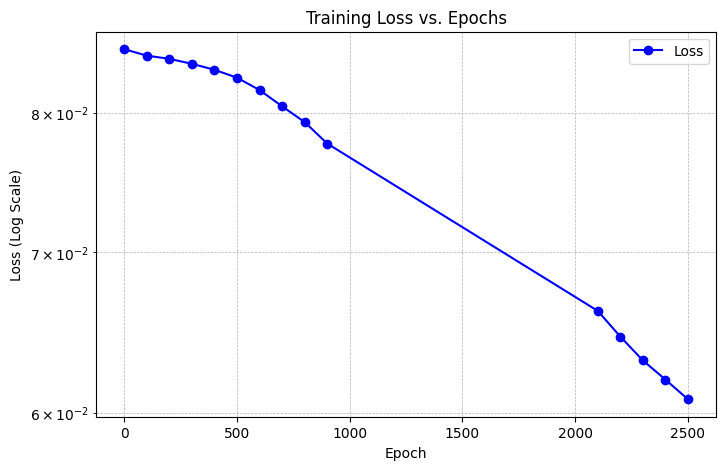

In [42]:
epoch_time_steps = np.arange(0, 1000, 100).tolist()
epoch_time_steps.extend([2100,2200,2300,2400,2500])
loss_list.extend([0.066174,
0.064564,
0.063105,
0.061955,
0.060795])
# print(epoch_time_steps)
# print(len(loss_list))
print(epoch_time_steps)
print(loss_list)

plt.figure(figsize=(8,5))
plt.plot(epoch_time_steps, loss_list,
         marker='o', linestyle='-',
         color='blue', label='Loss')

plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Training Loss vs. Epochs')

plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.savefig(f'{pic_path}loss_plot.png')
plt.show()

healpix primer, dodelson- good, antonio rhioto, power spectrum analytical derivation

In [ ]:
# 400k without log scale

# Epoch [100/1000] | Train Loss: 846073.203000
# Checkpoint saved at epoch 100
# Epoch [200/1000] | Train Loss: 615617.022250
# Checkpoint saved at epoch 200
# Epoch [300/1000] | Train Loss: 394714.503250
# Checkpoint saved at epoch 300
# Epoch [400/1000] | Train Loss: 218154.701750
# Checkpoint saved at epoch 400
# Epoch [500/1000] | Train Loss: 126937.484906
# Checkpoint saved at epoch 500
# Epoch [600/1000] | Train Loss: 117562.821563
# Checkpoint saved at epoch 600
# Epoch [700/1000] | Train Loss: 115338.471969
# Checkpoint saved at epoch 700
# Epoch [800/1000] | Train Loss: 113896.234969
# Checkpoint saved at epoch 800
# Epoch [900/1000] | Train Loss: 113013.797844
# Checkpoint saved at epoch 900
# Epoch [1000/1000] | Train Loss: 112172.923469
# Checkpoint saved at epoch 1000